In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline
# --- STEP 1: FIX THE PATH ---
# Ensure this path is correct and the files are downloaded from OneDrive
base_folder = r'C:\Users\mussh\Desktop\MobiFall_Dataset_v2.0'

def read_sensor_file(file_path, column_names):
    """Robustly reads MobiFall files by finding the @DATA marker."""
    try:
        data_start_line = 0
        with open(file_path, 'r') as f:
            for i, line in enumerate(f):
                if '@DATA' in line:
                    data_start_line = i + 1
                    break
        if data_start_line == 0: return None
        df = pd.read_csv(file_path, skiprows=data_start_line, header=None,
                         sep=',', usecols=[1, 2, 3], names=column_names, dtype=float)
        return df
    except Exception:
        return None


In [6]:
# --- Cell 2: Load, Combine, and Label All Data (Tailored for MobiFall v2.0) ---
# Path to the folder containing sub1, sub2, etc.
# Using 'r' prefix for raw string to handle Windows backslashes
base_folder = r'C:\Users\mussh\Desktop\MobiFall_Dataset_v2.0' 

# Initialize subject_folders to an empty list to avoid NameError if path is not found
subject_folders = []

# Get subject folders (sub1, sub2, ..., sub31)
try:
    subject_folders = [f for f in os.listdir(base_folder) if f.startswith('sub')]
    if not subject_folders:
        print(f"Error: No folders starting with 'sub' found in {base_folder}")
    else:
        print(f"Found {len(subject_folders)} subject folders. Starting import...")
except FileNotFoundError:
    print(f"Error: The path {base_folder} was not found. Please double-check it.")

# Define activity codes based on the MobiFall Readme
fall_activities = ['FOL', 'BSC', 'SDL', 'FKL']
adl_activities = ['CSI', 'CSO', 'JOG', 'JUM', 'SCH', 'STD', 'STN', 'STU', 'WAL']

data_list = [] 
trials_combined = 0
skipped_files = 0

def read_sensor_file(file_path, column_names):
    """Robustly reads MobiFall files by skipping metadata until @DATA marker."""
    data_start_line = 0
    try:
        with open(file_path, 'r') as f:
            for i, line in enumerate(f):
                if '@DATA' in line:
                    data_start_line = i + 1
                    break
        if data_start_line == 0:
            return None
            
        df = pd.read_csv(
            file_path,
            header=None,
            skiprows=data_start_line,
            sep=',',
            usecols=[1, 2, 3], # X, Y, Z columns
            names=column_names,
            dtype=float,
            on_bad_lines='skip'
        )
        return None if df.empty else df
    except Exception as e:
        return None

# Loop through each subject folder
for subject in subject_folders:
    subject_path = os.path.join(base_folder, subject)
    
    # --- PROCESS FALLS (Present in all 31 subjects) ---
    falls_base_path = os.path.join(subject_path, 'FALLS')
    if os.path.isdir(falls_base_path):
        for activity in fall_activities:
            activity_path = os.path.join(falls_base_path, activity)
            if os.path.isdir(activity_path):
                # Find all accelerometer files in this activity folder
                acc_files = [f for f in os.listdir(activity_path) if '_acc_' in f and f.endswith('.txt')]
                for acc_filename in acc_files:
                    # Identify matching gyro file by replacing _acc_ with _gyro_
                    gyro_filename = acc_filename.replace('_acc_', '_gyro_')
                    acc_path = os.path.join(activity_path, acc_filename)
                    gyro_path = os.path.join(activity_path, gyro_filename)
                    
                    if os.path.exists(gyro_path):
                        df_acc = read_sensor_file(acc_path, ['acc_x', 'acc_y', 'acc_z'])
                        df_gyro = read_sensor_file(gyro_path, ['gyro_x', 'gyro_y', 'gyro_z'])
                        
                        if df_acc is not None and df_gyro is not None:
                            min_len = min(len(df_acc), len(df_gyro))
                            df_trial = pd.concat([df_acc.iloc[:min_len], df_gyro.iloc[:min_len]], axis=1)
                            df_trial['label'] = 1 # Label 1 for Fall
                            data_list.append(df_trial)
                            trials_combined += 1
                        else:
                            skipped_files += 1

    # --- PROCESS ADL (Present only in subjects 2, 3, 4, 5, 7, 8, 9, 10, 11) ---
    adl_base_path = os.path.join(subject_path, 'ADL')
    if os.path.isdir(adl_base_path):
        for activity in adl_activities:
            activity_path = os.path.join(adl_base_path, activity)
            if os.path.isdir(activity_path):
                acc_files = [f for f in os.listdir(activity_path) if '_acc_' in f and f.endswith('.txt')]
                for acc_filename in acc_files:
                    gyro_filename = acc_filename.replace('_acc_', '_gyro_')
                    acc_path = os.path.join(activity_path, acc_filename)
                    gyro_path = os.path.join(activity_path, gyro_filename)
                    
                    if os.path.exists(gyro_path):
                        df_acc = read_sensor_file(acc_path, ['acc_x', 'acc_y', 'acc_z'])
                        df_gyro = read_sensor_file(gyro_path, ['gyro_x', 'gyro_y', 'gyro_z'])

                        if df_acc is not None and df_gyro is not None:
                            min_len = min(len(df_acc), len(df_gyro))
                            df_trial = pd.concat([df_acc.iloc[:min_len], df_gyro.iloc[:min_len]], axis=1)
                            df_trial['label'] = 0 # Label 0 for ADL
                            data_list.append(df_trial)
                            trials_combined += 1
                        else:
                            skipped_files += 1

# Final data assembly
if not data_list:
    print("\n--- ERROR: NO DATA WAS LOADED. Check folder structure and permissions. ---")
else:
    df_combined = pd.concat(data_list, ignore_index=True)
    print(f"\nProcessing Complete.")
    print(f"Combined {trials_combined} total trials.")
    print(f"Total data points (rows): {len(df_combined)}")
    print("\nData Balance (0=ADL, 1=Fall):")
    print(df_combined['label'].value_counts())
    
    # Save the master file locally for backup or for use in Colab
    df_combined.to_csv("combined_mobifall_raw.csv", index=False)

Found 24 subject folders. Starting import...

Processing Complete.
Combined 630 total trials.
Total data points (rows): 1044765

Data Balance (0=ADL, 1=Fall):
label
0    803334
1    241431
Name: count, dtype: int64


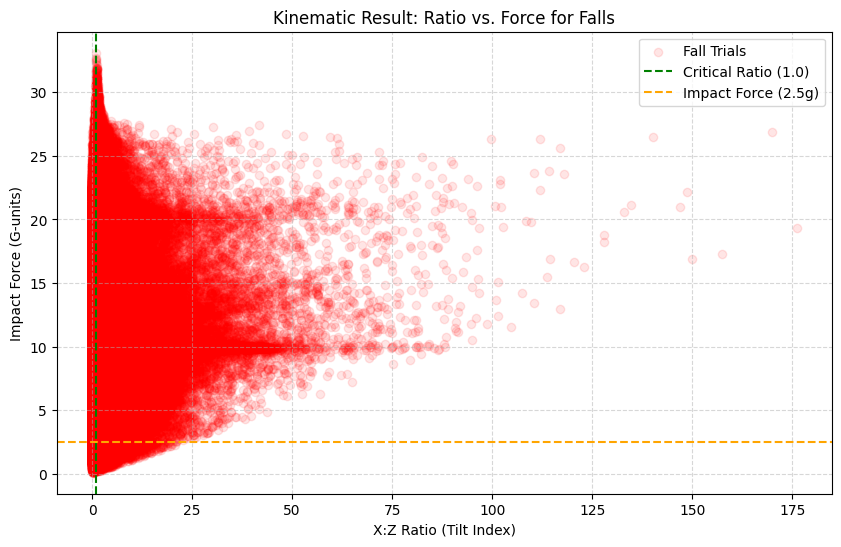

Average Fall Ratio: 2.18
Average Fall Force: 10.19g


In [7]:
# --- STEP 3: THE RATIO ANALYSIS (FIXED COLUMN NAMES) ---
if data_list:
    df_combined = pd.concat(data_list, ignore_index=True)
    
    # Calculate Ratios and Force using the correct column names
    # SMV (Signal Magnitude Vector) = sqrt(x^2 + y^2 + z^2)
    df_combined['smv'] = np.sqrt(df_combined['acc_x']**2 + df_combined['acc_y']**2 + df_combined['acc_z']**2)
    
    # Calculate Tilt Ratio
    df_combined['ratio_xz'] = np.abs(df_combined['acc_x']) / (np.abs(df_combined['acc_z']) + 0.1)

    # Plotting the Results
    plt.figure(figsize=(10, 6))
    plt.scatter(df_combined['ratio_xz'], df_combined['smv'], color='red', alpha=0.1, label='Fall Trials')
    plt.axvline(x=1.0, color='green', linestyle='--', label='Critical Ratio (1.0)')
    plt.axhline(y=2.5, color='orange', linestyle='--', label='Impact Force (2.5g)')
    
    plt.title("Kinematic Result: Ratio vs. Force for Falls")
    plt.xlabel("X:Z Ratio (Tilt Index)")
    plt.ylabel("Impact Force (G-units)")
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.show()

    print(f"Average Fall Ratio: {df_combined['ratio_xz'].mean():.2f}")
    print(f"Average Fall Force: {df_combined['smv'].mean():.2f}g")
else:
    print("No data processed. Please ensure files are local and the path is correct.")

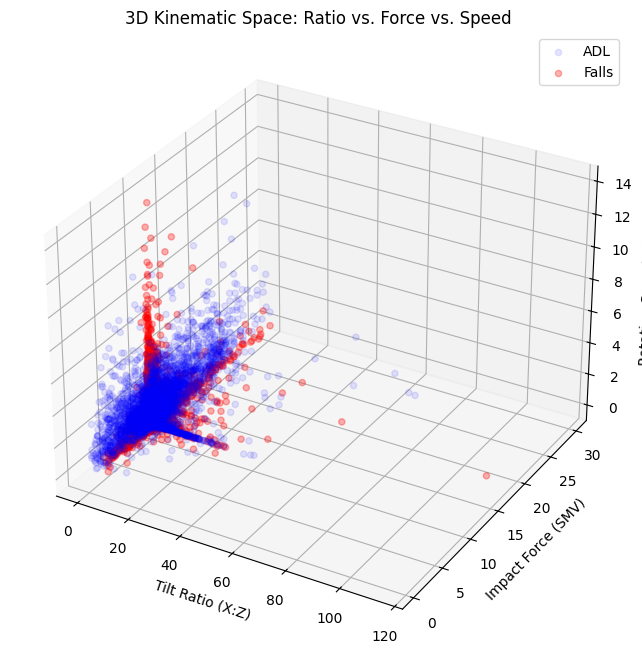

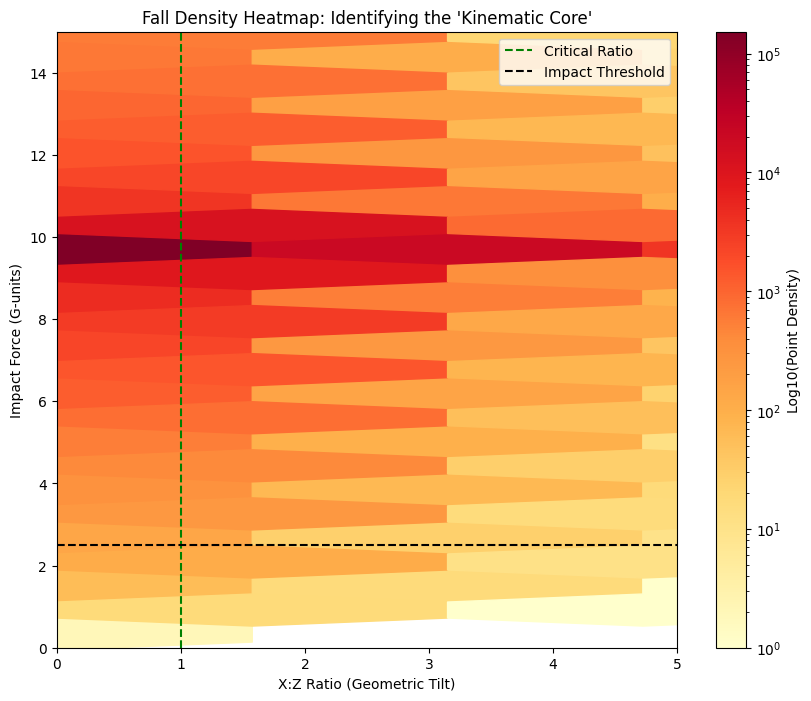

In [12]:
def plot_advanced_visuals(df):
    """
    Generates a 3D Scatter Plot and a 2D Heatmap to visualize 
    the kinematic density of fall events.
    """
    # 1. Prepare Data using your actual column names
    # Accelerometer Math
    df['smv'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
    df['ratio_xz'] = np.abs(df['acc_x']) / (np.abs(df['acc_z']) + 0.1)
    
    # Gyroscope Math
    df['gyro_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)
    
    # Filter for Falls and ADLs
    # Note: Using .copy() to avoid SettingWithCopy warnings
    falls = df[df['label'] == 1]
    adls = df[df['label'] == 0]
    
    # Sampling for performance (if data is huge)
    falls_sample = falls.sample(min(5000, len(falls)))
    adls_sample = adls.sample(min(5000, len(adls)))

    # --- FIGURE 1: 3D SCATTER PLOT ---
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(adls_sample['ratio_xz'], adls_sample['smv'], adls_sample['gyro_mag'], 
               c='blue', alpha=0.1, label='ADL')
    ax.scatter(falls_sample['ratio_xz'], falls_sample['smv'], falls_sample['gyro_mag'], 
               c='red', alpha=0.3, label='Falls')
    
    ax.set_title("3D Kinematic Space: Ratio vs. Force vs. Speed")
    ax.set_xlabel("Tilt Ratio (X:Z)")
    ax.set_ylabel("Impact Force (SMV)")
    ax.set_zlabel("Rotation Speed (Gyro)")
    ax.legend()
    plt.show()

    # --- FIGURE 2: 2D HEATMAP ---
    plt.figure(figsize=(10, 8))
    hb = plt.hexbin(falls['ratio_xz'], 
                    falls['smv'], 
                    gridsize=50, cmap='YlOrRd', bins='log')
    
    plt.colorbar(hb, label='Log10(Point Density)')
    plt.axvline(x=1.0, color='green', linestyle='--', label='Critical Ratio')
    plt.axhline(y=2.5, color='black', linestyle='--', label='Impact Threshold')
    
    plt.title("Fall Density Heatmap: Identifying the 'Kinematic Core'")
    plt.xlabel("X:Z Ratio (Geometric Tilt)")
    plt.ylabel("Impact Force (G-units)")
    plt.xlim(0, 5)
    plt.ylim(0, 15)
    plt.legend()
    ax.view_init(elev=20, azim=45)
    plt.show()

# Run the function
plot_advanced_visuals(df_combined)